In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
from math import *

In [2]:
# Argument : the folder path 
# Return : an array of all images readed by OpenCV
def load_images_from_folder(folder):
    images = []
    for filename in os.listdir(folder):
        img = cv2.imread(os.path.join(folder,filename), 0) # Gray Color converting
        if img is not None:
            images.append(img)
    return np.array(images)

In [3]:
def points_poly(contour):
    peri = cv2.arcLength(contour,True)
    vertices = cv2.approxPolyDP(contour,0.008*peri,True)
    return vertices

In [4]:
def bresenham(start, end):
    """Bresenham's Algorithm
    Produces a list of tuples from start and end
 
    >>> points1 = get_line((0, 0), (3, 4))
    >>> points2 = get_line((3, 4), (0, 0))
    >>> assert(set(points1) == set(points2))
    >>> print points1
    [(0, 0), (1, 1), (1, 2), (2, 3), (3, 4)]
    >>> print points2
    [(3, 4), (2, 3), (1, 2), (1, 1), (0, 0)]
    """
    # Setup initial conditions
    x1, y1 = start
    x2, y2 = end
    dx = x2 - x1
    dy = y2 - y1
 
    # Determine how steep the line is
    is_steep = abs(dy) > abs(dx)
 
    # Rotate line
    if is_steep:
        x1, y1 = y1, x1
        x2, y2 = y2, x2
 
    # Swap start and end points if necessary and store swap state
    swapped = False
    if x1 > x2:
        x1, x2 = x2, x1
        y1, y2 = y2, y1
        swapped = True
 
    # Recalculate differentials
    dx = x2 - x1
    dy = y2 - y1
 
    # Calculate error
    error = int(dx / 2.0)
    ystep = 1 if y1 < y2 else -1
 
    # Iterate over bounding box generating points between start and end
    y = y1
    points = []
    for x in range(x1, x2 + 1):
        coord = (y, x) if is_steep else (x, y)
        points.append(coord)
        error -= abs(dy)
        if error < 0:
            y += ystep
            error += dx
 
    # Reverse the list if the coordinates were swapped
    if swapped:
        points.reverse()
    return points

In [20]:
def points_composante(points):
        nbr_points = len(points)
        print("\n")
        composante = []
        for i in range(0,nbr_points-1):
            p1 = points[i][0]
            p2 = points[i+1][0]
            composante.append(np.asarray(bresenham(p1,p2)))
        composante.append(np.asarray(bresenham(points[-1][0],points[0][0])))
        return composante

In [158]:
from math import sqrt

def slope(a,b):
    x1 = a[0]
    x2 = b[0]
    y1 = a[1]
    y2 = b[1]
    return (y2-y1)/(x2-x1)

def isCollinear(points):
    #on suppose qu'on aura 3 points en entrée
    return slope(points[0],points[1])== slope(points[1],points[2])== slope(points[2],points[0])

def distance(a,b):
    x1 = a[0]
    x2 = b[0]
    y1 = a[1]
    y2 = b[1]
    return sqrt((x1-x2)**2+(y1-y2)**2)

def sumDistance(a,points):
    sum = 0
    for point in points:
        sum += distance(a,point)
    return sum

def isLeft(a,b,c):
    #Calcul si C est a gauche de [AB]
    x1 = a[0]
    x2 = b[0]
    y1 = a[1]
    y2 = b[1]
    
    x3 = c[0]
    y3 = c[1]
    puissance = ((x2-x1)*(y3-y1))-((x3-x1)*(y2-y1))
    if (puissance > 0):
        return True
    else :
        return False

def isInside(a,points):
    
    inside = True
    if not(isLeft(a,points[0],points[1])):
        inside = False
    elif not(isLeft(a,points[1],points[2])):
        inside = False
    elif not(isLeft(a,points[2],points[0])):
        inside = False
    return inside

def isArrow(points):
    #on suppose qu'on aura 4 points en entrée
    l1 = points[1:4]
    d1 = sumDistance(points[0],l1)
    
    l2 = points[0:1]+points[2:4]
    d2 = sumDistance(points[1],l2)
    
    l3 = points[0:2]+points[3:4]
    d3 = sumDistance(points[2],l3)
    
    l4 = points[0:3]
    d4 = sumDistance(points[3],l4)
    
    dl = [d1,d2,d3,d4]
    if(dl.index(min(dl)) == 0):
        if(isCollinear(l1)):
            return False
        return isInside(points[0],l1)
    elif(dl.index(min(dl)) == 1):
        if(isCollinear(l2)):
            return False
        return isInside(points[1],l2)
    elif(dl.index(min(dl)) == 2):
        if(isCollinear(l3)):
            return False
        return isInside(points[2],l3)
    elif(dl.index(min(dl)) == 3):
        if(isCollinear(l4)):
            return False
        return isInside(points[3],l4)
    else :
        print("Error")
        return False

In [159]:
a = [0,0]
b = [2,2]
c = [5,0]
d = [3,5]

m1 = [0,1,2,3,4]
m2 = [5,6,7,8,9]
m3 = [m1,m2]
m4 = [m2,m1]

points = [a,b,c,d]
isArrow(points)

True

Nombre de points du ROI n° 0
12
[[[777 283]]

 [[778 285]]

 [[790 285]]

 [[791 284]]

 [[797 284]]

 [[802 280]]

 [[806 280]]

 [[806 278]]

 [[802 275]]

 [[800 276]]

 [[783 275]]

 [[780 278]]]
Coordonnées des points du composants n° 0 : 


[array([[777, 283],
       [777, 284],
       [778, 285]]), array([[778, 285],
       [779, 285],
       [780, 285],
       [781, 285],
       [782, 285],
       [783, 285],
       [784, 285],
       [785, 285],
       [786, 285],
       [787, 285],
       [788, 285],
       [789, 285],
       [790, 285]]), array([[790, 285],
       [791, 284]]), array([[791, 284],
       [792, 284],
       [793, 284],
       [794, 284],
       [795, 284],
       [796, 284],
       [797, 284]]), array([[797, 284],
       [798, 283],
       [799, 282],
       [800, 282],
       [801, 281],
       [802, 280]]), array([[802, 280],
       [803, 280],
       [804, 280],
       [805, 280],
       [806, 280]]), array([[806, 280],
       [806, 279],
       [806, 278]]

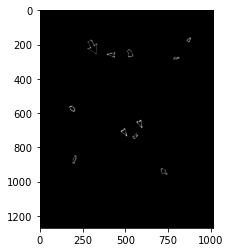

In [79]:
images = load_images_from_folder("./Ressources/test")
threshold_area_min = 200 # Réfléchir à l'utilisation d'un pourcentage de l'image ou utiliser des connaissances apriori de l'image 
threshold_max_point = 13
for image in images:  


    #Inverting image
    #image = cv2.bitwise_not(image);
    # Denoising the image
    image = cv2.GaussianBlur(image, (5, 5), 3)
    
    # Binarisation
    _, binary = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY) # Ne detecte que les flèches noires, il faut modifier le param 2 et 3 pour inverser cela et ajouter l'inverse de l'image
        
    # Contours Detection
    edged = cv2.Canny(binary,10,200) # Vérifier les paramètres entrés
    contours, hierarchy = cv2.findContours(edged, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) # Get only extreme points of the contours
    
    # Sort the contours by area and then remove the largest frame contour
    n = len(contours)-1
    contours = sorted(contours, key=cv2.contourArea, reverse=False)[:n]
    num = 0
    
    height,width = edged.shape[:2]
    imgComposante = np.zeros([height+100,width+100,1],dtype = "uint8")
    
    for contour in contours:
        
        x,y,w,h = cv2.boundingRect(contour)
        hull = cv2.convexHull(contour)
        
        # ROI Extraction after area filtering
        area = cv2.contourArea(contour)
        points = points_poly(contour)
        nbr_points = len(points)
   
        if (area > threshold_area_min)&(nbr_points <13):

            print("Nombre de points du ROI n°",num)
            print(nbr_points)
            print(points)
            print(f"Coordonnées des points du composants n° {num} : ")
            print(points_composante(points))
            cv2.polylines(imgComposante,points_composante(points),True,(255,255,255),1)
            for point in points:
                cv2.circle(imgComposante,(point[0][0],point[0][1]), 3, (200,200,255), 1)
            ROI = imgComposante[y:y+h, x:x+w]
            cv2.imwrite('./resultats/petitTestInverse/ROI_{}.png'.format(num), ROI)
            num += 1
    cv2.drawContours(image,contour,-1,(0,255,0),1)
    #plt.imshow(edged, cmap='gray')
    plt.imshow(imgComposante,cmap='gray')
    print(image)
    print(imgComposante)
            

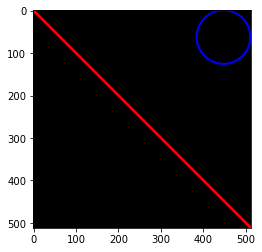

In [26]:

# Create a black image
img = np.zeros((512,512,3), np.uint8)
# Draw a diagonal blue line with thickness of 5 px
cv2.line(img,(0,0),(511,511),(255,0,0),5)
cv2.circle(img,(447,63), 63, (0,0,255), 3)
plt.imshow(img)
